In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.stem import PorterStemmer
from collections import Counter
import pickle
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE

In [75]:
nltk.download('stopwords',download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [76]:
with open('../static/model/corpora/stopwords/english','r') as file:
    sw = file.read().splitlines()

In [77]:
print(sw[:50])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn']


In [33]:
ps = PorterStemmer()

##  Data Loading and Cleaning 

In [34]:
# Load dataset
data = pd.read_csv('../artifacts/tripadvisor_extended_1000.csv')

In [35]:
print("Train data shape:", data.shape)
print("\nTrain data sample:")
data.tail(10)

Train data shape: (7552, 3)

Train data sample:


,id,tweet,label
7542,7543,"Enjoyed my time here. The pool was clean, and ...",2
7543,7544,"Enjoyed my time here. The pool was clean, and ...",2
7544,7545,"Bad experience! The location was good, but eve...",0
7545,7546,Best experience ever! The hotel ambiance was p...,2
7546,7547,"Bad experience! The location was good, but eve...",0
7547,7548,The noise was unbearable. Couldn’t sleep all n...,0
7548,7549,Totally regret booking this place. Stay away! ...,0
7549,7550,"A reasonable place for a short stay, but nothi...",1
7550,7551,It was fine for a business trip. Nothing too f...,1
7551,7552,"Not worth the money. The rooms smelled bad, an...",0


In [36]:
print("Train data shape: ",data.shape)
print("\nDuplicates: ",data.duplicated().sum())
print("\nNull values:\n",data.isnull().sum())

Train data shape:  (7552, 3)

Duplicates:  0

Null values:
 id       0
tweet    0
label    0
dtype: int64


## Preprocessing Function

In [37]:

def preprocess_text(text):
    # 1. Convert text to lowercase (splitting and joining to mimic your original method)
    text = " ".join(word.lower() for word in text.split())
    
    # 2. Remove links: apply regex to each word in the sentence
    text = " ".join(re.sub(r'^https?:\/\/.*[\r\n]*', '', word, flags=re.MULTILINE) for word in text.split())
    
    # 3. Remove punctuations: iterate through all punctuation symbols
    for p in string.punctuation:
        text = text.replace(p, '')
    
    # 4. Remove numbers using regex
    text = re.sub(r'\d+', '', text)
    
    # 5. Remove stopwords using the loaded list (SW)
    text = " ".join(word for word in text.split() if word not in sw)
    
    # 6. Apply stemming (Porter Stemmer)
    text = " ".join(ps.stem(word) for word in text.split())
    
    return text

## Apply preprocessing to the 'tweet' column

In [38]:
data["tweet"] = data["tweet"].apply(preprocess_text)
print("Sample preprocessed tweets:\n", data["tweet"].head())

Sample preprocessed tweets:
 0    nice averag stay recent midoctob got good deal...
1    westin rio mar worth trip friend return day we...
2    okay great stay apolo tryp night pretti standa...
3    good great stay friend neri earli thought grea...
4    poor custom servic poor custom servic respond ...
Name: tweet, dtype: object


## Vocabulary Building

In [39]:
# Build vocabulary using Counter
vocab = Counter()
for sentence in data['tweet']:
    vocab.update(sentence.split())
print("Most common tokens:\n", vocab.most_common(50))
print("Dataset Shape: ", data.shape)
print("Vocabulary Size: ", len(vocab))

Most common tokens:
 [('room', 17502), ('hotel', 16450), ('stay', 9467), ('nt', 7363), ('good', 5676), ('great', 5507), ('staff', 5147), ('night', 5086), ('day', 4647), ('time', 4630), ('nice', 4435), ('servic', 4185), ('locat', 4169), ('like', 3668), ('beach', 3667), ('place', 3641), ('resort', 3449), ('clean', 3426), ('food', 3378), ('restaur', 3197), ('bed', 2902), ('walk', 2817), ('pool', 2773), ('breakfast', 2705), ('peopl', 2515), ('realli', 2467), ('got', 2407), ('small', 2362), ('look', 2356), ('book', 2320), ('want', 2281), ('area', 2272), ('help', 2245), ('desk', 2172), ('littl', 2064), ('need', 2035), ('check', 2034), ('price', 2011), ('bathroom', 2001), ('make', 1978), ('ask', 1921), ('water', 1912), ('use', 1878), ('bar', 1863), ('friendli', 1840), ('thing', 1789), ('arriv', 1780), ('review', 1779), ('tri', 1775), ('view', 1765)]
Dataset Shape:  (7552, 3)
Vocabulary Size:  30056


In [40]:
# Filter tokens with frequency > 2
tokens = [key for key in vocab if vocab[key] > 1]
print('\nFiltered Token Size: ', len(tokens))


Filtered Token Size:  11666


In [41]:
# Save the filtered vocabulary to a file
def save_vocabulary(lines, filename):
    vocab_data = '\n'.join(lines)
    with open(filename, 'w', encoding="utf-8") as file:
        file.write(vocab_data)

save_vocabulary(tokens, '../static/model/vocabulary.txt')

##  Data Splitting

In [42]:
# Divide dataset into features and labels
x = data['tweet']
y = data['label']

In [43]:
# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (6041,)
x_test shape: (1511,)


### Define vectorization function: create a binary vector (1 if token is present)

In [44]:
# Define vectorization function: create a binary vector (1 if token is present)
def vectorizer(ds, vocabulary):
    vectorized = []
    for sentence in ds:
        sentence_vector = np.zeros(len(vocabulary))
        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_vector[i] = 1
        vectorized.append(sentence_vector)
    return np.asarray(vectorized, dtype=np.float32)

In [45]:
vectorized_x_train = vectorizer(x_train, tokens)
print("Finish vectorized_x_train")
vectorized_x_test = vectorizer(x_test, tokens)
print("Finish vectorized_x_test")

Finish vectorized_x_train
Finish vectorized_x_test


In [46]:
y_train.value_counts()

label
0    2029
1    2022
2    1990
Name: count, dtype: int64

## Visualize Class Distribution

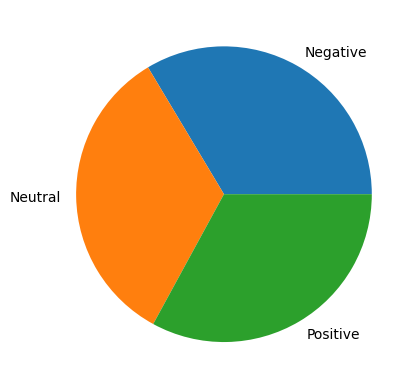

<Figure size 600x300 with 0 Axes>

In [95]:

plt.pie(np.array([y_train.value_counts()[0], 
                  y_train.value_counts()[1], 
                  y_train.value_counts()[2]]),
        labels=['Negative', 'Neutral', 'Positive'])
plt.show()

## Handling Imbalanced Dataset 

In [48]:
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)
print("Value counts after SMOTE:\n", y_train_smote.value_counts())

(6087, 11666) (6087,)
Value counts after SMOTE:
 label
0    2029
2    2029
1    2029
Name: count, dtype: int64


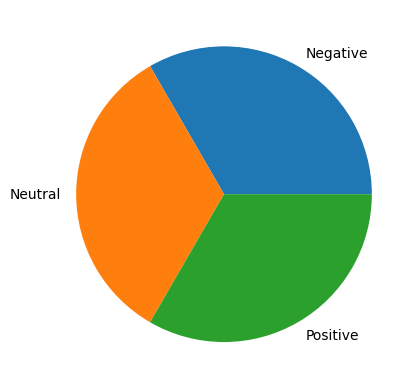

In [49]:
plt.pie(np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1], y_train_smote.value_counts()[2]]),
        labels=['Negative', 'Neutral', 'Positive'])
plt.show()

## Model Training and Evaluation

In [50]:
def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Training Scores: \n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')
    
def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Testing Scores: \n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


In [84]:
def plot_confusion_matrix_chart(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    # For 3 classes, update labels accordingly.
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()

## --- Naive Bayes (MultinomialNB) ---


=== Training Set ===
Training Scores: 
	Accuracy = 0.886
	Precision = 0.886
	Recall = 0.886
	F1-Score = 0.886

=== Test Set ===
Testing Scores: 
	Accuracy = 0.792
	Precision = 0.794
	Recall = 0.792
	F1-Score = 0.793




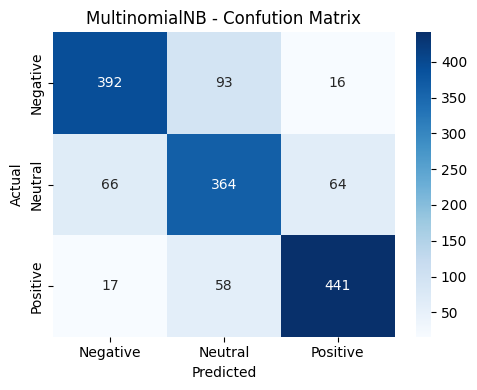

In [97]:
# MultinomialNB (Original)
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = mnb.predict(vectorized_x_train_smote)
y_test_pred = mnb.predict(vectorized_x_test)

print("\n=== Training Set ===")
training_scores(y_train_smote, y_train_pred)

print("\n=== Test Set ===")
validation_scores(y_test, y_test_pred)

print("\n")
# print(classification_report(y_test, y_test_pred, digits=3))

plot_confusion_matrix_chart(y_test, y_test_pred, 'MultinomialNB - Confution Matrix')

## --- Logistic Regression ---


=== Training Set ===
Training Scores: 
	Accuracy = 0.998
	Precision = 0.998
	Recall = 0.998
	F1-Score = 0.998

=== Test Set ===
Testing Scores: 
	Accuracy = 0.75
	Precision = 0.753
	Recall = 0.75
	F1-Score = 0.751




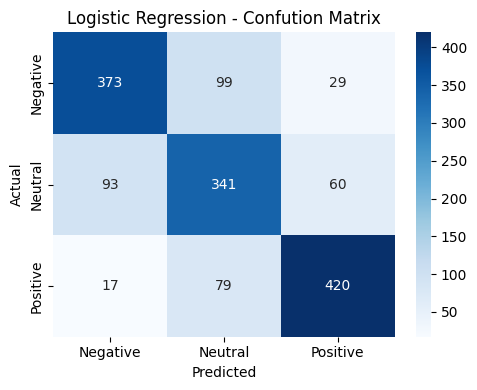

In [98]:
# Logistic Regression (Original)
lr = LogisticRegression(max_iter=1000)
lr.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = lr.predict(vectorized_x_train_smote)
y_test_pred = lr.predict(vectorized_x_test)

print("\n=== Training Set ===")
training_scores(y_train_smote, y_train_pred)

print("\n=== Test Set ===")
validation_scores(y_test, y_test_pred)

print("\n")
# print(classification_report(y_test, y_test_pred, digits=3))

plot_confusion_matrix_chart(y_test, y_test_pred, 'Logistic Regression - Confution Matrix')

## --- Random Forest ---


=== Training Set ===
Training Scores: 
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0

=== Test Set ===
Testing Scores: 
	Accuracy = 0.747
	Precision = 0.747
	Recall = 0.747
	F1-Score = 0.747




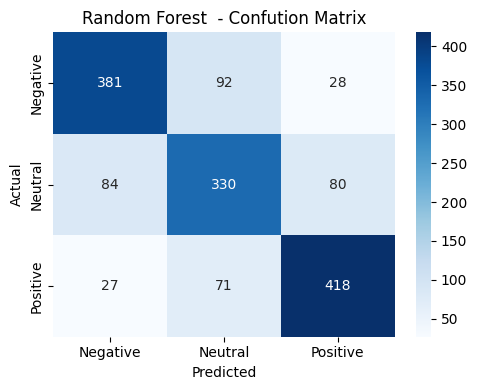

In [100]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = rf.predict(vectorized_x_train_smote)
y_test_pred = rf.predict(vectorized_x_test)

print("\n=== Training Set ===")
training_scores(y_train_smote, y_train_pred)

print("\n=== Test Set ===")
validation_scores(y_test, y_test_pred)

print("\n")
# print(classification_report(y_test, y_test_pred, digits=3))

plot_confusion_matrix_chart(y_test, y_test_pred, 'Random Forest  - Confution Matrix')

## --- Decision Tree ---


=== Training Set ===
Training Scores: 
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0

=== Test Set ===
Testing Scores: 
	Accuracy = 0.594
	Precision = 0.594
	Recall = 0.594
	F1-Score = 0.594




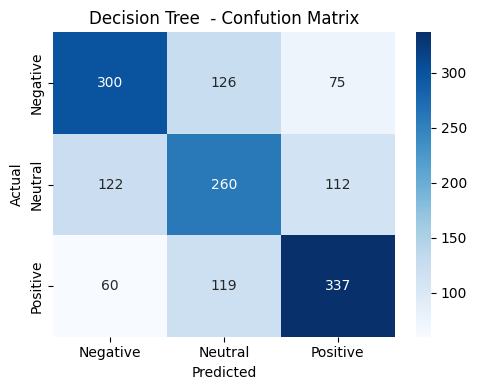

In [99]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = dt.predict(vectorized_x_train_smote)
y_test_pred = dt.predict(vectorized_x_test)

print("\n=== Training Set ===")
training_scores(y_train_smote, y_train_pred)

print("\n=== Test Set ===")
validation_scores(y_test, y_test_pred)

print("\n")
# print(classification_report(y_test, y_test_pred, digits=3))

plot_confusion_matrix_chart(y_test, y_test_pred, 'Decision Tree  - Confution Matrix')

# download Best Model

In [89]:
import pickle
with open('../static/model/model_final_complete.pickle','wb') as file:
    pickle.dump(mnb,file)